In [453]:
import sys
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymetagen import MetaGen
from dask.distributed import Client
import dask.dataframe as dd
from dask.delayed import delayed
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
from functools import partial
from collections import Counter
from tqdm import tqdm
import multiprocessing as mp
import warnings
warnings.filterwarnings('ignore')

Из имеющихся наборов данных оставляем датасет KT1 и KT3.  
**EdNET-KT1** consists of students' question-solving logs, which is the most basic and fundamental information:  
* **timestamp** is the moment the question was given, represented as Unix timestamp in milliseconds.
* **solving_id** represents each learning session of students corresponds to each bunle. It is a form of single integer, starting from 1.
* **question_id** is the ID of the question that given to student, which is a form of q{integer}.
* **user_answer** is the answer that the student submitted, recorded as a character between a and d inclusively.
* **elapsed_time** is the time that the students spends on each question in milliseconds.  
* **action_type** is one of the following: enter, respond, and submit.  

**enter** is recorded when student first receives and views a question bundle through UI.  
**respond** is recorded when the student selects an answer choice to one of the questions in the bundle. A student can respond to the same question multiple times. In this case, only the last response before submitting his final answer is considered as his response.  
**submit** is recorded when the student submits his final answers to the the given bundle.  

* **item_id** is The ID of item involved with the action. For EdNet-KT2, only the IDs of questions and bundles are recorded. A bundle is assigned for actions of type enter and submit.  

* **source** shows where the student solve a question or watch a lecture in Santa UI. There are several sources in Santa that students can solve questions or watch lectures. For KT2, only the sources that provides question-solving environments are recorded.

In **sprint**, students choose a part that they want to study. After that, they can only solve questions belongs to the part that they choose, until they change to different part or select different source.  
The student can re-do the questions that he already solved before using review system, which is recorded as **in_review**.  

* **user_answer** is recorded when action_type is respond, which stands for the student's submitted answer. It is one of the alphabets a, b, c, and d.

* **platform** shows where the student used Santa, which is either mobile or web.

As we said above, explanations and lectures are added.

* Reading Explanations

    After each student solves given questions, corresponding explanations are given to him. The sources of explanations for questions from sprint and review are recorded as after_sprint and after_review, respectively. One can also re-read explanations of questions that he solved from my_note.  
    Whenever a student enters the explanation view in Santa UI or exits the view, a corresponding action of type enter and quit with explanation ID as item_id is recorded. Note that the explanation ID is exactly same as the bundle ID.

* Watching Lectures  

    There are two possible sources that the student can watch a lecture: archive, adaptive_offer, and todays_recommendatin::lecture. He can access all the possible lectures from archive. Also, Santa can suggest lectures by Today's recommendation or adaptive offer along with questions.  
    Whenever a student plays a lecture video or stops watching the video, a corresponding action of type enter and quit with lecture ID as item_id is recorded.


### Data sampling

When analyzing a random sample that made up 5% of the total data volume, poor data quality was revealed and the sample size was increased to 30%

In [187]:
# Directories for copying selections
raw_folder = r"D:\GitRepo\student-performance-forecast\data\raw"
KT3_raw = os.path.join(raw_folder, "EdNET_KT3")
KT3_processed = os.path.join(raw_folder, "EdNET_KT3_selection")

# Ensure destination directory exists
os.makedirs(KT3_processed, exist_ok=True)

# For statistical significance, 30% of all files are randomly extracted
files = set(os.listdir(KT3_raw))
files_indexes = np.random.permutation(len(files))
selection = files_indexes[0:int(len(files)*0.3)]
files = list(files)
files = [files[i] for i in selection]

# The selected files are copied for further processing and analysis
for file in tqdm(files, desc="Copying KT3 files", unit="file"):
    source = os.path.join(KT3_raw, file)
    destination = os.path.join(KT3_processed, file)
    if os.path.isfile(source):
        shutil.copy(source, destination)

To generate datasets for training, information about the correctness of user responses will be added to the information about the responses.

In [160]:
# import iformation about questions
questions_df=pd.read_csv(
    r"D:\GitRepo\student-performance-forecast\data\raw\EdNet-Contents\contents\questions.csv",
    usecols=['question_id','correct_answer']
)
correct_dict = dict(zip(questions_df['question_id'], questions_df['correct_answer']))

For each file from the sample, a table with statistics for each feature is generated.  
From this data, the following are selected for each user:  
* file - file name
* n_actions - the number of actions performed
* platform_val - the platforms used
* source_val - the sources of tasks
* n_user_answer_empty - the number of actions not related to solving tasks

In [162]:
def process_both_files(file_name, path):
    """Collecting basic statistics from sample files"""
    try:
        full_path = os.path.join(path, file_name)
        
        if not os.path.exists(full_path):
            return None
        
        metagen = MetaGen.from_path(full_path, loading_mode="eager")
        metadata = metagen.compute_metadata().reset_index()
        
        result = {
            'file': file_name,
            'n_actions': int(metadata.loc[0, "# positive"]),
            'platform_val': metadata.loc[5, "Values"],
            'source_val': metadata.loc[3, "Values"],
            'n_user_answer_empty': metadata.loc[4, "# empty/zero"]
        }
        
        return result
        
    except Exception as e:
        print(f"Error during processing {file_name}: {e}")
        return None

In [163]:
KT3_path = os.path.join(raw_folder, "EdNET_KT3_selection")

# Getting a list of files
files = [f for f in os.listdir(KT3_path) if f.endswith('.csv')]
print(f"{len(files)} files found for processing")
KT3_data = []

with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    process_func = partial(process_both_files, path=KT3_path)
    results = list(tqdm(executor.map(process_func, files), 
                        total=len(files),
                        desc="File Processing",
                        unit=" file"))
    for kt3_res in results:
        if kt3_res is not None:
            KT3_data.append(kt3_res)
            
# Creating a DataFrame
KT3_df = pd.DataFrame(KT3_data)

86965 files found for processing


File Processing: 100%|██████████| 86965/86965 [30:40<00:00, 47.25 file/s] 


### Log file analysis

In [164]:
KT3_df.describe()

,n_actions,n_user_answer_empty
count,86965.000000,86965.000000
mean,309.006612,228.626321
std,1431.577303,1059.086757
min,2.000000,2.000000
25%,19.000000,12.000000
50%,27.000000,18.000000
75%,82.000000,60.000000
max,92145.000000,75020.000000


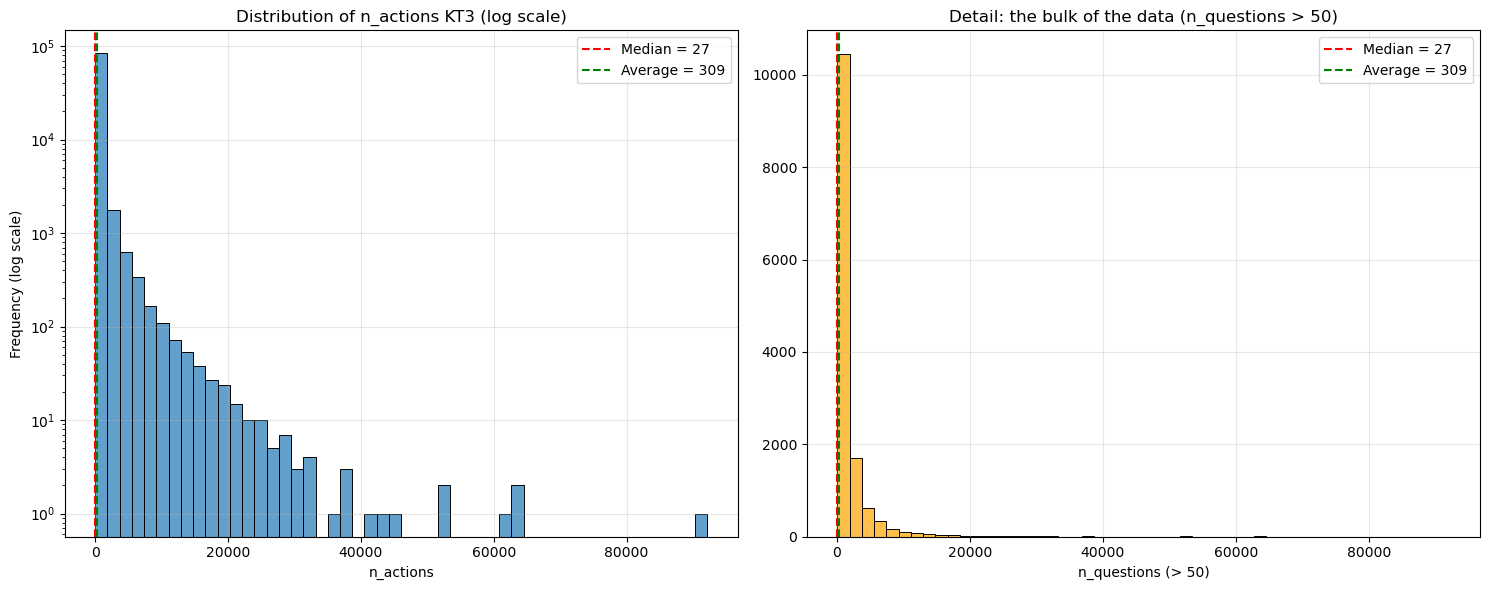

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graph 1: Logarithmic histogram (basic)
# Shows the entire distribution, including the tail
sns.histplot(data=KT3_df, x='n_actions', bins=50, ax=ax1, alpha=0.7, edgecolor='black')
ax1.set_yscale('log')
ax1.set_xlabel('n_actions')
ax1.set_ylabel('Frequency (log scale)')
ax1.set_title('Distribution of n_actions KT3 (log scale)')
ax1.grid(True, alpha=0.3)

# Adding vertical lines for the median and the mean
median_val = KT3_df['n_actions'].median()
mean_val = KT3_df['n_actions'].mean()
ax1.axvline(median_val, color='red', linestyle='--', label=f'Median = {median_val:.0f}')
ax1.axvline(mean_val, color='green', linestyle='--', label=f'Average = {mean_val:.0f}')
ax1.legend()

# Graph 2: Tail of the distribution (n_actions > 50)
# Shows details of the bulk of the data
mask = (KT3_df['n_actions']-KT3_df['n_user_answer_empty']) > 50
filtered_data = KT3_df.loc[mask, 'n_actions']

sns.histplot(data=filtered_data, bins=50, ax=ax2, alpha=0.7, color='orange', edgecolor='black')
ax2.set_xlabel('n_questions (> 50)')
ax2.set_ylabel('')
ax2.set_title('Detail: the bulk of the data (n_questions > 50)')
ax2.axvline(median_val, color='red', linestyle='--', label=f'Median = {median_val:.0f}')
ax2.axvline(mean_val, color='green', linestyle='--', label=f'Average = {mean_val:.0f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We select those users who have solved at least 50 tasks, and remove those with more than 95 percentile of completed tasks.

In [172]:
mask=KT3_df['n_actions']-KT3_df['n_user_answer_empty']
temp_series=KT3_df[['n_actions']].copy()
temp_series['n_user_answer']=KT3_df[mask>50].n_actions-KT3_df[mask>50].n_user_answer_empty
print("the number of actions in which the user answers the questions")
temp_series.describe(percentiles=[.25,.5,.75,.9,.95,.99])

the number of actions in which the user answers the questions


,n_actions,n_user_answer
count,86965.000000,13639.000000
mean,309.006612,450.833859
std,1431.577303,908.823338
min,2.000000,51.000000
25%,19.000000,87.000000
50%,27.000000,168.000000
75%,82.000000,425.000000
90%,503.600000,1027.200000
95%,1353.000000,1760.200000
99%,5625.880000,4376.780000


In [186]:
n_user_answer=KT3_df['n_actions']-KT3_df['n_user_answer_empty']
KT3_selected_df=KT3_df[(n_user_answer > 50) & (n_user_answer < 1760) & (KT3_df.n_actions<3000)]
display(KT3_selected_df.describe())
print(f'Total actions: {KT3_selected_df.shape[0]*KT3_selected_df.n_actions.sum():,}')

,n_actions,n_user_answer_empty
count,11658.000000,11658.000000
mean,854.454195,647.638531
std,675.562493,514.013736
min,64.000000,4.000000
25%,343.250000,262.000000
50%,594.000000,452.000000
75%,1176.000000,886.000000
max,2999.000000,2628.000000


Total actions: 116,127,984,366


Now we need to determine the ratio of platforms used by users in order to assess the relevance of their use as a feature. As well as the ratio of task sources

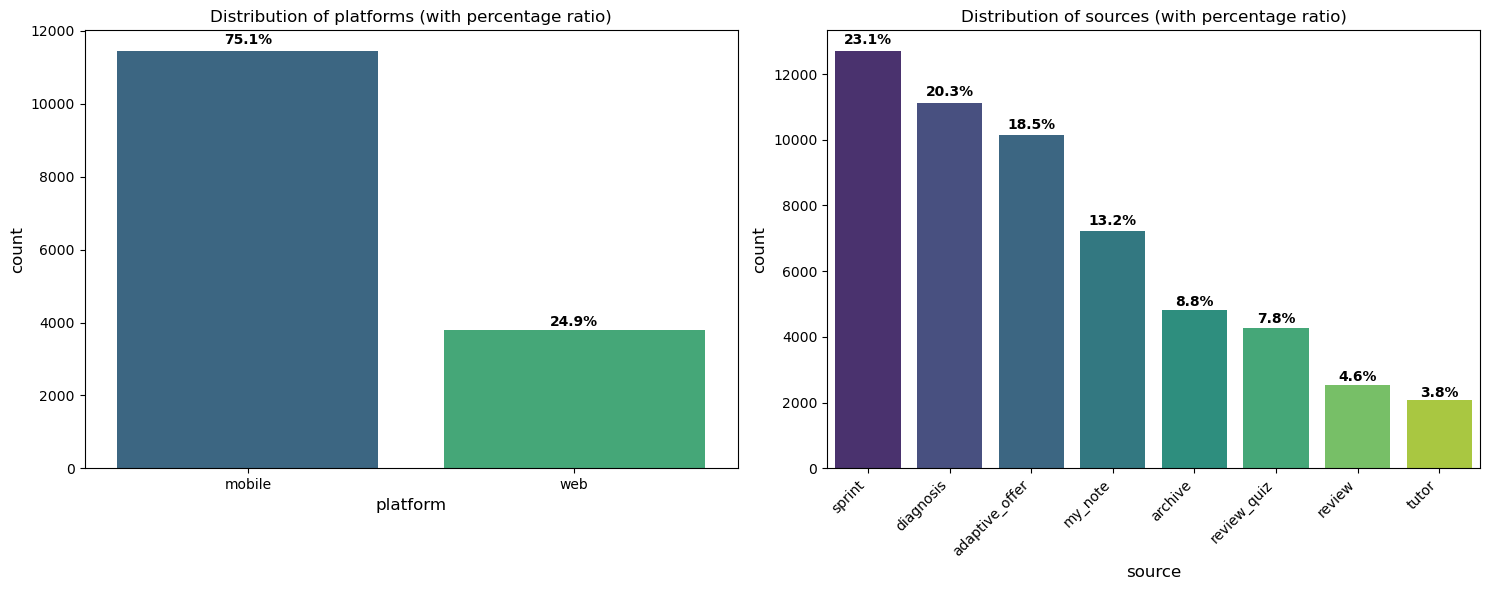

In [97]:
all_platforms = [platform for platforms_list in KT3_selected_df.platform_val for platform in platforms_list]
all_sources = [source for source_list in KT3_selected_df.source_val for source in source_list]

platform_counts = pd.Series(all_platforms).value_counts()
source_counts = pd.Series(all_sources).value_counts()

plat_total = platform_counts.sum()
plat_percentages = (platform_counts / plat_total * 100).round(1)

source_total = source_counts.sum()
source_percentages = (source_counts / source_total * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=platform_counts.index, y=platform_counts.values, ax=ax1, palette='viridis')

for i, (count, percentage) in enumerate(zip(platform_counts.values, plat_percentages)):
    ax1.text(i, count + count * 0.01, f'{percentage}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.set_title('Distribution of platforms (with percentage ratio)')
ax1.set_xlabel('platform', fontsize=12)
ax1.set_ylabel('count', fontsize=12)
plt.xticks(rotation=45, ha='right')

sns.barplot(x=source_counts.index, y=source_counts.values, ax=ax2, palette='viridis')

for i, (count, percentage) in enumerate(zip(source_counts.values, source_percentages)):
    ax2.text(i, count + count * 0.01, f'{percentage}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax2.set_title('Distribution of sources (with percentage ratio)')
ax2.set_xlabel('source', fontsize=12)
ax2.set_ylabel('count', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Aggregation of log files

In [351]:
def transformation(df, correct_dict):
    """
    Трансформация логов EdNET KT3 в датасет для обучения
    Одна запись на bundle
    """
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    is_bundle_enter = df['item_id'].str.startswith('b', na=False) & (df['action_type'] == 'enter')
    is_bundle_submit = df['item_id'].str.startswith('b', na=False) & (df['action_type'] == 'submit')
    is_lecture_enter = df['item_id'].str.startswith('l', na=False) & (df['action_type'] == 'enter')
    is_lecture_quit = df['item_id'].str.startswith('l', na=False) & (df['action_type'] == 'quit')
    is_explanation_enter = df['item_id'].str.startswith('e', na=False) & (df['action_type'] == 'enter')
    is_explanation_quit = df['item_id'].str.startswith('e', na=False) & (df['action_type'] == 'quit')
    is_respond = df['item_id'].str.startswith('q', na=False) & (df['action_type'] == 'respond')
    
    # Собираем bundle
    bundle_starts = df[is_bundle_enter][['item_id', 'timestamp','platform', 'source']].rename(columns={'timestamp': 'enter_time'})
    bundle_ends = df[is_bundle_submit][['item_id', 'timestamp']].rename(columns={'timestamp': 'submit_time'})
    bundles = bundle_starts.merge(bundle_ends, on='item_id', how='inner')
    if len(bundles) == 0:
        return pd.DataFrame()
    bundles = bundles.groupby('item_id').agg({
        'enter_time': 'min',
        'submit_time': 'max',
        'platform': 'first',
        'source': 'first'
    }).reset_index()
    
    bundles = bundles[bundles['submit_time'] > bundles['enter_time']].copy()
    
    # Lectures
    lectures_enter = df[is_lecture_enter][['item_id', 'timestamp']].rename(columns={'timestamp': 'enter_time'})
    lectures_quit = df[is_lecture_quit][['item_id', 'timestamp']].rename(columns={'timestamp': 'quit_time'})
    
    # Responds
    responds = df[is_respond][['item_id','timestamp','user_answer']]
    
    # Adding temporary indexes for sequential matching
    lectures_enter['n'] = lectures_enter.groupby('item_id').cumcount()
    lectures_quit['n'] = lectures_quit.groupby('item_id').cumcount()
    lectures = lectures_enter.merge(lectures_quit, on=['item_id', 'n'], how='inner')
    lectures = lectures.drop('n', axis=1)
    
    # Explanations
    explanations_enter = df[is_explanation_enter][['item_id', 'timestamp']].rename(columns={'timestamp': 'enter_time'})
    explanations_quit = df[is_explanation_quit][['item_id', 'timestamp']].rename(columns={'timestamp': 'quit_time'})
    
    # Adding temporary indexes for sequential matching
    explanations_enter['n'] = explanations_enter.groupby('item_id').cumcount()
    explanations_quit['n'] = explanations_quit.groupby('item_id').cumcount()
    explanations = explanations_enter.merge(explanations_quit, on=['item_id', 'n'], how='inner')
    explanations = explanations.drop('n', axis=1)
    
    bundles = bundles.sort_values('enter_time').reset_index(drop=True)
    
    last_submit_time = None
    results=[]
    
    
    for idx, row in bundles.iterrows():
        enter_time = row['enter_time']
        submit_time = row['submit_time']
        platform = row.platform
        source = row.source
        
        # Bundle's time
        bundle_time_limited = min(submit_time - enter_time, 600000)
        
        if idx == 0:
            start_interval = enter_time
        else:
            start_interval = bundles.iloc[idx-1]['submit_time']
        
        end_interval = submit_time
        
        if len(lectures) > 0:
            lecture_mask = (lectures['enter_time'] >= start_interval) & \
                           (lectures['quit_time'] <= end_interval) & \
                           (lectures['enter_time'] < lectures['quit_time'])
            lectures_count = lecture_mask.sum()
        else:
            lectures_count = 0
        
        if len(explanations) > 0:
            exp_mask = (explanations['enter_time'] >= start_interval) & \
                       (explanations['quit_time'] <= end_interval) & \
                       (explanations['enter_time'] < explanations['quit_time'])
            explanations_count = exp_mask.sum()
        else:
            explanations_count = 0
    
        mask = (responds['timestamp'] > start_interval) & (responds['timestamp'] < end_interval)
        bundle_responds = responds[mask].copy()

        n_questions = 0
        n_attempts = 0
        accuracy = 0
        n_correct = 0
        
        if len(bundle_responds) > 0:
            n_questions = bundle_responds['item_id'].nunique()
            n_attempts = len(bundle_responds)
            
            for qid, group in bundle_responds.groupby('item_id'):
                group_sorted = group.sort_values('timestamp')
                last_answer = group_sorted.iloc[-1]['user_answer']
                
                if last_answer == correct_dict.get(qid, ''):
                    n_correct += 1
            
            accuracy = n_correct / n_questions if n_questions > 0 else 0
        
        results.append({
            'timestamp': submit_time,
            'platform': platform,
            'source': source,
            'bundle_time_ms': bundle_time_limited,
            'viewed_lectures': lectures_count,
            'viewed_explanations': explanations_count,
            'n_questions': n_questions,
            'n_attempts': n_attempts,
            'n_correct': n_correct,
            'accuracy': round(accuracy, 3)
        })
    
    if results:
        return pd.DataFrame(results).sort_values('timestamp').reset_index(drop=True)
    return pd.DataFrame()

In [350]:
# Example
test_df=pd.read_csv(r"D:\GitRepo\student-performance-forecast\data\raw\EdNET_KT3_selection\u7625.csv")
aggregate_df = transformation(test_df,correct_dict)
display(aggregate_df.describe())
display(aggregate_df.head(6))

,timestamp,bundle_time_ms,viewed_lectures,viewed_explanations,n_questions,n_attempts,n_correct,accuracy
count,1.110000e+02,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000
mean,1.551684e+12,86486.531532,0.081081,2.531532,2.189189,2.720721,1.261261,0.550658
std,1.051305e+10,130949.549900,0.333988,9.212462,8.107812,9.974669,4.589933,0.484876
min,1.544096e+12,10351.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.544446e+12,24361.500000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
50%,1.545043e+12,34162.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,1.567256e+12,90094.500000,0.000000,1.000000,1.000000,1.500000,1.000000,1.000000
max,1.567901e+12,600000.000000,2.000000,80.000000,71.000000,86.000000,40.000000,1.000000


,timestamp,platform,source,bundle_time_ms,viewed_lectures,viewed_explanations,n_questions,n_attempts,n_correct,accuracy
0,1544096117889,mobile,sprint,148836,0,0,0,0,0,0.000
1,1544096221733,mobile,sprint,93670,0,1,1,1,0,0.000
2,1544096439376,mobile,sprint,79696,0,0,0,0,0,0.000
3,1544096520013,mobile,sprint,74615,0,1,1,1,0,0.000
4,1544096896697,mobile,sprint,600000,1,4,3,4,2,0.667
5,1544097089929,mobile,sprint,90635,1,3,2,2,1,0.500


In [352]:
source = r"D:\GitRepo\student-performance-forecast\data\raw\EdNET_KT3_selection"
new_path = r"D:\GitRepo\student-performance-forecast\data\processed\EdNET_KT3"
os.makedirs(new_path, exist_ok=True)

# check converted files
conv_files=os.listdir(new_path)
conv_files=set([file.replace('parquet','csv') for file in os.listdir(new_path)])
selected_files=set(KT3_selected_df.file)
nonconv_files=selected_files.difference(conv_files)

# converting the remaining files
for file in tqdm(nonconv_files, desc='Processing files'):
    try:
        full_path = os.path.join(source, file)
        df = pd.read_csv(full_path)
        df_transformed = transformation(df, correct_dict)
        
        if len(df_transformed) > 0:
            save_path = os.path.join(new_path, file.replace('.csv', '.parquet'))
            df_transformed.to_parquet(save_path, index=False)
    except Exception as e:
        print(f"\nError in {file}: {e}")

Processing files: 100%|██████████| 11658/11658 [1:03:54<00:00,  3.04it/s]


### Analysis of aggregated data

In [411]:
def load_file_stats(path):
    df = dd.read_parquet(path)
    user_id = int(os.path.basename(path)[1:].replace('.parquet', ''))
    if len(df) > 0:
        file_num_stats = {
            'file_name': user_id,
            'bundles': len(df),
            'questions': df['n_questions'].sum().compute().item(),
            'attempts': df['n_attempts'].sum().compute().item(),
            'correct': df['n_correct'].sum().compute().item(),
            'lectures': df['viewed_lectures'].sum().compute().item(),
            'explanations': df['viewed_explanations'].sum().compute().item(),
            'accuracy_mean': round(df['accuracy'].mean().compute().item(),4),
            'accuracy_std': round(df['accuracy'].std().compute().item(),4),
            'bundle_time_mean': round(df['bundle_time_ms'].mean().compute().item() / 1000,4),
            'bundle_time_std': round(df['bundle_time_ms'].std().compute().item() / 1000,4),
            'n_questions_mean': round(df['n_questions'].mean().compute().item(),4),
            'n_attempts_mean': round(df['n_attempts'].mean().compute().item(),4)
        }
        file_category_stats={
            'file_name': user_id,
            'platforms': df['platform'].value_counts().compute().to_dict(),
            'sources': df['source'].value_counts().compute().to_dict()
        }
    else:
        file_num_stats = {
            'file_name': user_id,
            'bundles': 0,
            'error': 'Empty file'
        }
        file_category_stats={
            'file_name': user_id,
            'platforms': {},
            'sources': {}
        }
        
    return file_num_stats, file_category_stats

In [417]:
path=r"D:\GitRepo\student-performance-forecast\data\processed\EdNET_KT3"
files=os.listdir(path)
full_num_stats=[]
full_categorical_stats=[]
for file in tqdm(files):
    source=os.path.join(path,file)
    num,cat = load_file_stats(source)
    full_num_stats.append(num)
    full_categorical_stats.append(cat)
full_stats_df=pd.DataFrame(full_num_stats)

100%|██████████| 11658/11658 [30:56<00:00,  6.28it/s] 


In [469]:
all_source = Counter()
all_platforms = Counter()
for item in full_categorical_stats:
    all_source.update(item['sources'])
    all_platforms.update(item['platforms'])
display(pd.Series(all_platforms))
print()
display(pd.Series(all_source))

mobile    1326067
web        288776
dtype: int64

diagnosis           87447
sprint            1416798
adaptive_offer       6925
my_note             74274
review_quiz          8077
tutor               21078
review                244
dtype: int64

In [419]:
full_stats_df.describe()

,file_name,bundles,questions,attempts,correct,lectures,explanations,accuracy_mean,accuracy_std,bundle_time_mean,bundle_time_std,n_questions_mean,n_attempts_mean
count,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000,11658.000000
mean,427462.987476,138.518013,634.088008,869.375193,440.925287,31.300480,722.261280,0.605835,0.458749,80.774166,117.895224,3.243788,4.507500
std,232610.377327,104.487808,1241.232737,1773.436794,902.683497,98.468564,1481.396158,0.110785,0.039296,66.640107,68.115070,3.960110,6.144340
min,37.000000,2.000000,2.000000,47.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.946000,0.000000,0.220600,0.323700
25%,299595.750000,60.250000,79.000000,100.000000,51.000000,0.000000,78.000000,0.543700,0.445500,41.772075,70.820375,1.090375,1.440000
50%,456120.500000,100.000000,179.000000,231.000000,116.000000,3.000000,191.000000,0.615400,0.467200,61.383200,112.443000,1.722800,2.311250
75%,600152.750000,187.000000,572.000000,761.000000,387.000000,18.000000,629.000000,0.679900,0.484000,94.876900,161.336425,3.596000,4.878975
max,832257.000000,585.000000,17597.000000,23732.000000,14834.000000,2923.000000,18439.000000,1.000000,0.577400,600.000000,293.656400,43.584500,151.680300


In [440]:
print(f"Total number of bundles: {full_stats_df.bundles.sum():,}")
print(f"Average accuracy: {(full_stats_df.correct.sum()/full_stats_df.questions.sum()).item():.3f}")
avg_time = ((full_stats_df['bundle_time_mean'] * full_stats_df['bundles']).sum() / full_stats_df['bundles'].sum()).item()
print(f"Average bundle execution time: {avg_time:.3f}s")

Total number of bundles: 1,614,843
Average accuracy: 0.695
Average bundle execution time: 83.689s


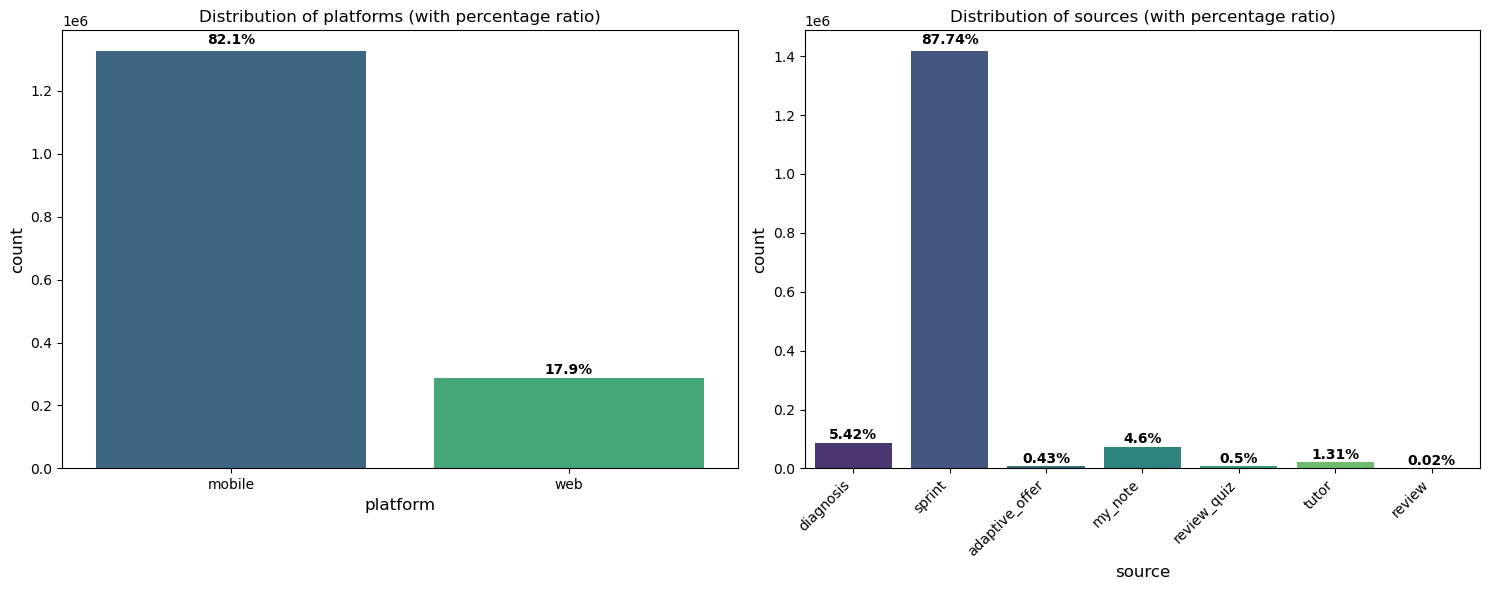

In [472]:
platform_counts = pd.Series(all_platforms)
source_counts = pd.Series(all_source)

plat_total = platform_counts.sum()
plat_percentages = (platform_counts / plat_total * 100).round(1)

source_total = source_counts.sum()
source_percentages = (source_counts / source_total * 100).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=platform_counts.index, y=platform_counts.values, ax=ax1, palette='viridis')

for i, (count, percentage) in enumerate(zip(platform_counts.values, plat_percentages)):
    ax1.text(i, count + count * 0.01, f'{percentage}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax1.set_title('Distribution of platforms (with percentage ratio)')
ax1.set_xlabel('platform', fontsize=12)
ax1.set_ylabel('count', fontsize=12)
plt.xticks(rotation=45, ha='right')

sns.barplot(x=source_counts.index, y=source_counts.values, ax=ax2, palette='viridis')

for i, (count, percentage) in enumerate(zip(source_counts.values, source_percentages)):
    ax2.text(i, count + count * 0.01, f'{percentage}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax2.set_title('Distribution of sources (with percentage ratio)')
ax2.set_xlabel('source', fontsize=12)
ax2.set_ylabel('count', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

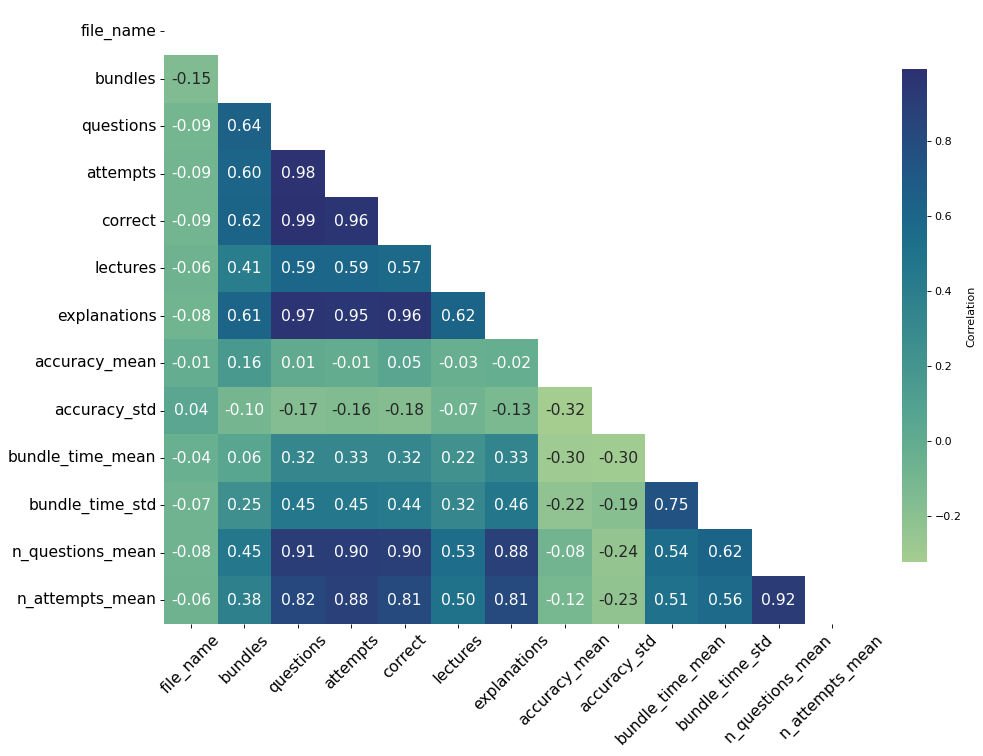

In [510]:
fig, ax = plt.subplots(figsize=(14, 10), dpi=80)
mask=np.triu(full_stats_df.corr())
sns.heatmap(
    full_stats_df.corr(),
    ax=ax,
    annot=True,
    fmt=".2f",
    mask=mask,
    cmap="crest",
    annot_kws={'size': 14},
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'}
)
ax.tick_params(axis='x', labelsize=14, rotation=45)
ax.tick_params(axis='y', labelsize=14, rotation=0)
plt.show()

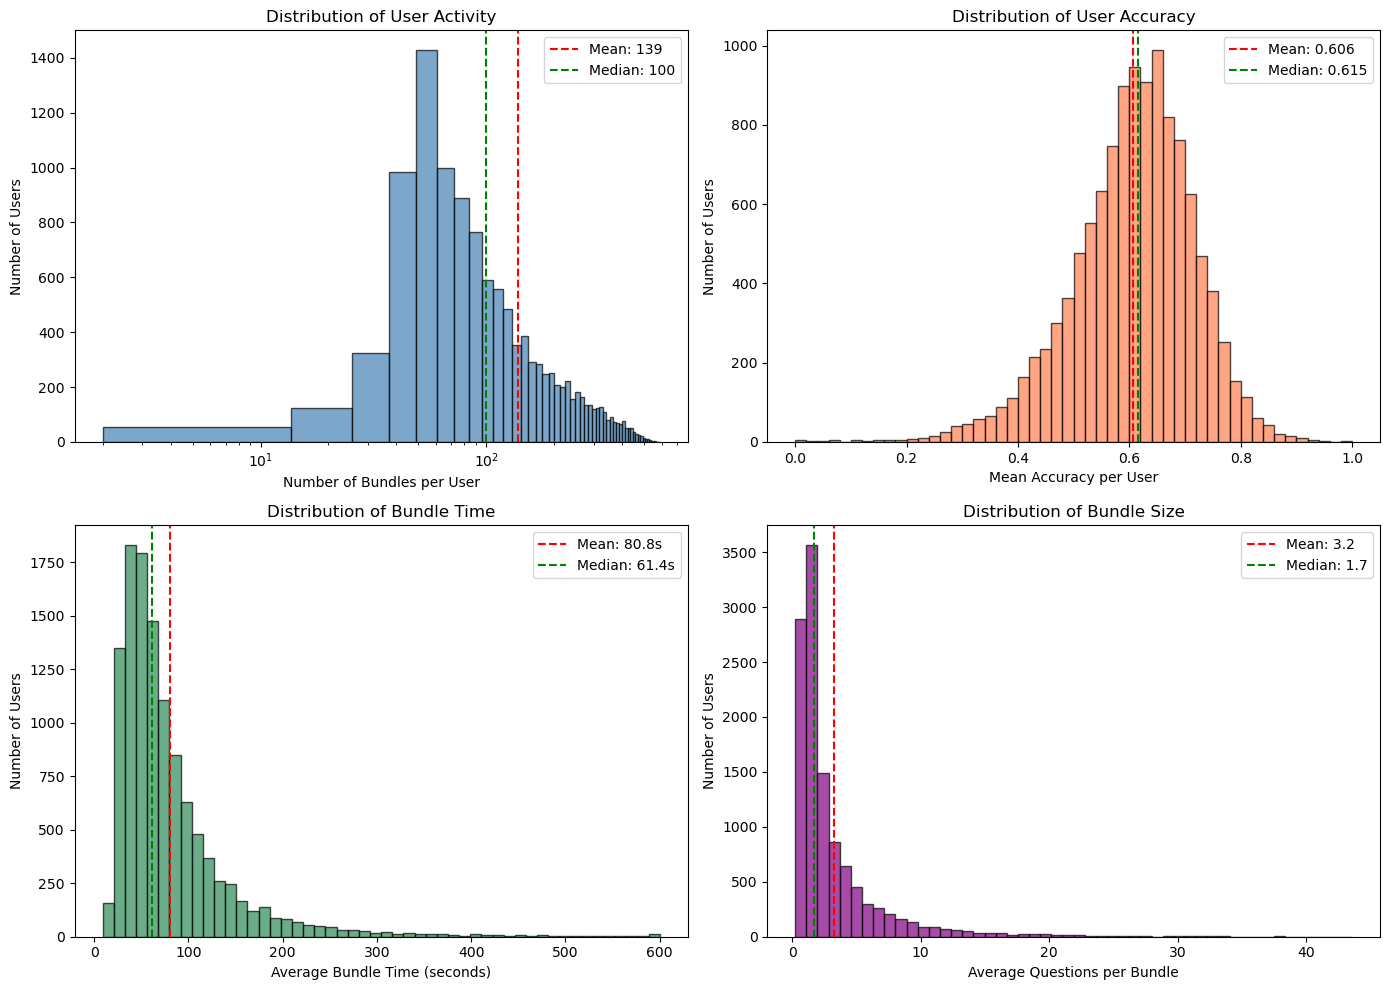

In [514]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(full_stats_df['bundles'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(full_stats_df['bundles'].mean(), color='red', linestyle='--', label=f'Mean: {full_stats_df["bundles"].mean():.0f}')
axes[0,0].axvline(full_stats_df['bundles'].median(), color='green', linestyle='--', label=f'Median: {full_stats_df["bundles"].median():.0f}')
axes[0,0].set_xlabel('Number of Bundles per User')
axes[0,0].set_ylabel('Number of Users')
axes[0,0].set_title('Distribution of User Activity')
axes[0,0].legend()
axes[0,0].set_xscale('log')

axes[0,1].hist(full_stats_df['accuracy_mean'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0,1].axvline(full_stats_df['accuracy_mean'].mean(), color='red', linestyle='--', label=f'Mean: {full_stats_df["accuracy_mean"].mean():.3f}')
axes[0,1].axvline(full_stats_df['accuracy_mean'].median(), color='green', linestyle='--', label=f'Median: {full_stats_df["accuracy_mean"].median():.3f}')
axes[0,1].set_xlabel('Mean Accuracy per User')
axes[0,1].set_ylabel('Number of Users')
axes[0,1].set_title('Distribution of User Accuracy')
axes[0,1].legend()

axes[1,0].hist(full_stats_df['bundle_time_mean'], bins=50, edgecolor='black', alpha=0.7, color='seagreen')
axes[1,0].axvline(full_stats_df['bundle_time_mean'].mean(), color='red', linestyle='--', label=f'Mean: {full_stats_df["bundle_time_mean"].mean():.1f}s')
axes[1,0].axvline(full_stats_df['bundle_time_mean'].median(), color='green', linestyle='--', label=f'Median: {full_stats_df["bundle_time_mean"].median():.1f}s')
axes[1,0].set_xlabel('Average Bundle Time (seconds)')
axes[1,0].set_ylabel('Number of Users')
axes[1,0].set_title('Distribution of Bundle Time')
axes[1,0].legend()

axes[1,1].hist(full_stats_df['n_questions_mean'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1,1].axvline(full_stats_df['n_questions_mean'].mean(), color='red', linestyle='--', label=f'Mean: {full_stats_df["n_questions_mean"].mean():.1f}')
axes[1,1].axvline(full_stats_df['n_questions_mean'].median(), color='green', linestyle='--', label=f'Median: {full_stats_df["n_questions_mean"].median():.1f}')
axes[1,1].set_xlabel('Average Questions per Bundle')
axes[1,1].set_ylabel('Number of Users')
axes[1,1].set_title('Distribution of Bundle Size')
axes[1,1].legend()

plt.tight_layout()
plt.show()

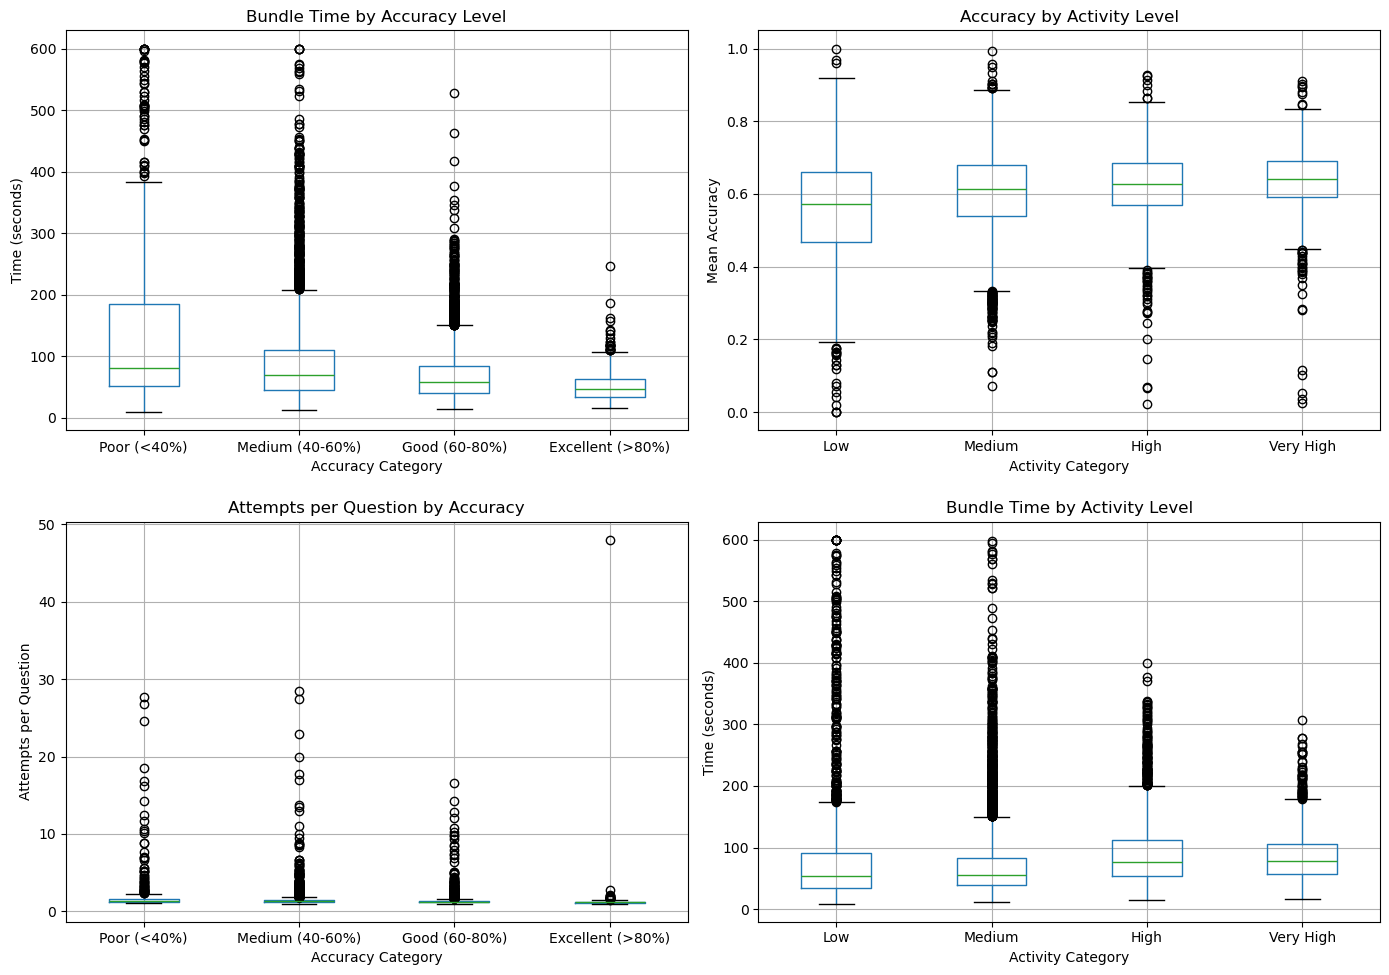

In [518]:
full_stats_df['accuracy_category'] = pd.cut(
    full_stats_df['accuracy_mean'],
    bins=[0, 0.4, 0.6, 0.8, 1.0],
    labels=['Poor (<40%)', 'Medium (40-60%)', 'Good (60-80%)', 'Excellent (>80%)']
)

full_stats_df['activity_category'] = pd.cut(
    full_stats_df['bundles'],
    bins=[0, 50, 150, 300, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

full_stats_df.boxplot(column='bundle_time_mean', by='accuracy_category', ax=axes[0,0])
axes[0,0].set_title('Bundle Time by Accuracy Level')
axes[0,0].set_xlabel('Accuracy Category')
axes[0,0].set_ylabel('Time (seconds)')

full_stats_df.boxplot(column='accuracy_mean', by='activity_category', ax=axes[0,1])
axes[0,1].set_title('Accuracy by Activity Level')
axes[0,1].set_xlabel('Activity Category')
axes[0,1].set_ylabel('Mean Accuracy')

full_stats_df['attempts_per_question'] = full_stats_df['n_attempts_mean'] / full_stats_df['n_questions_mean']
full_stats_df.boxplot(column='attempts_per_question', by='accuracy_category', ax=axes[1,0])
axes[1,0].set_title('Attempts per Question by Accuracy')
axes[1,0].set_xlabel('Accuracy Category')
axes[1,0].set_ylabel('Attempts per Question')

full_stats_df.boxplot(column='bundle_time_mean', by='activity_category', ax=axes[1,1])
axes[1,1].set_title('Bundle Time by Activity Level')
axes[1,1].set_xlabel('Activity Category')
axes[1,1].set_ylabel('Time (seconds)')

plt.suptitle('')
plt.tight_layout(h_pad=2.0)
plt.show()